# Let's get going and preprocess some data 😏
 إنسان الي كاتب والله 😂

## Starter Code (Provided by the supervisor)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val   = x_train_full[40000:].astype('float32')
y_val   = y_train_full[40000:]
x_test  = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Helping Functions (also proivded by the supervisor) ربنا يخليهولنا

In [10]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## The actual data preprocessing (Finally 🥱)
I'm the one who wrote the code, but since I didn't know a lot about tensorflow, I asked GPT-5 mini about how to write it first. (and then Gemini Pro 3.1 because mini 5 decided just decided suddenly to blank out)

In [11]:
def build_baseline_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a 4-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

## Preprocessing helper functions

In [12]:
def preprocess_none(x):
    return x.astype('float32')

def preprocess_minmax(x):
    return x.astype('float32') / 255.0

def compute_train_stats(x_train):
    x = x_train.astype('float32')
    mean = x.mean(axis = (0,1,2))
    std = x.std(axis = (0,1,2))
    return mean, std

def preprocess_standardize(x, mean, std):
    return (x.astype('float32') - mean) / std

## Let's try and check if everything runs well or not 🙃

In [13]:
# Let's start by building the model
model = build_baseline_cnn()

# Then let's create the different variations of data with different types of preprocessing for the different expirments.
x_train_exp_a = preprocess_none(x_train) # Features as they are with nothing changed
x_train_exp_b = preprocess_minmax(x_train) # Normalized features.
train_mean, train_std = compute_train_stats(x_train) # X_train mean and standard deviation.
x_train_exp_c = preprocess_standardize(x_train, train_mean, train_std) # X_train standardized per channel.
x_val_exp_a = preprocess_none(x_val)
x_val_exp_b = preprocess_minmax(x_val)
x_val_exp_c = preprocess_standardize(x_val, train_mean, train_std)
x_test_exp_a = preprocess_none(x_test)
x_test_exp_b = preprocess_minmax(x_test)
x_test_exp_c = preprocess_standardize(x_test, train_mean, train_std)

# Time to try and train the actual model that we've built
history_exp_a, test_acc_exp_a, test_loss_exp_a, elapsed_exp_a = train_and_evaluate(model, x_train_exp_a, y_train, x_val_exp_a, y_val, x_test_exp_a, y_test)
history_exp_b, test_acc_exp_b, test_loss_exp_b, elapsed_exp_b = train_and_evaluate(model, x_train_exp_b, y_train, x_val_exp_b, y_val, x_test_exp_b, y_test)
history_exp_c, test_acc_exp_c, test_loss_exp_c, elapsed_exp_c = train_and_evaluate(model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5314 | Test Loss: 3.1891 | Time: 81.8s
Test Acc: 0.6629 | Test Loss: 1.5846 | Time: 77.1s
Test Acc: 0.6560 | Test Loss: 3.2757 | Time: 75.7s


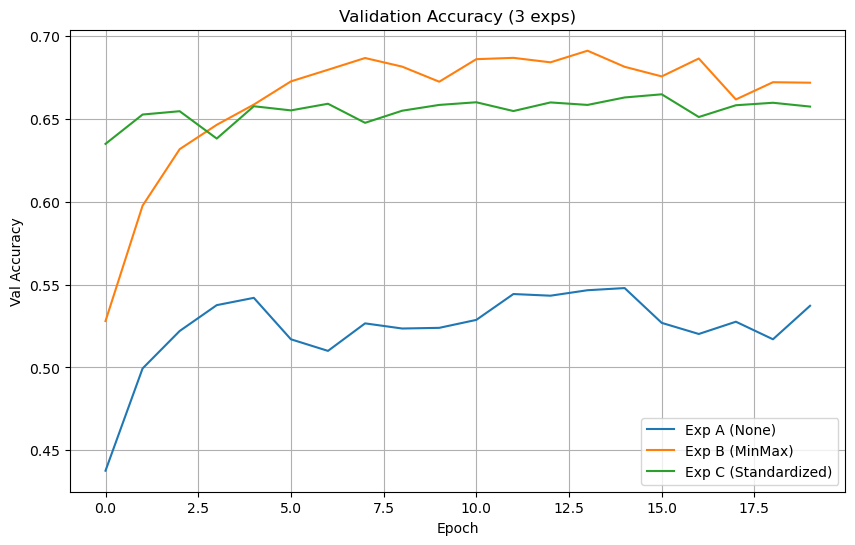

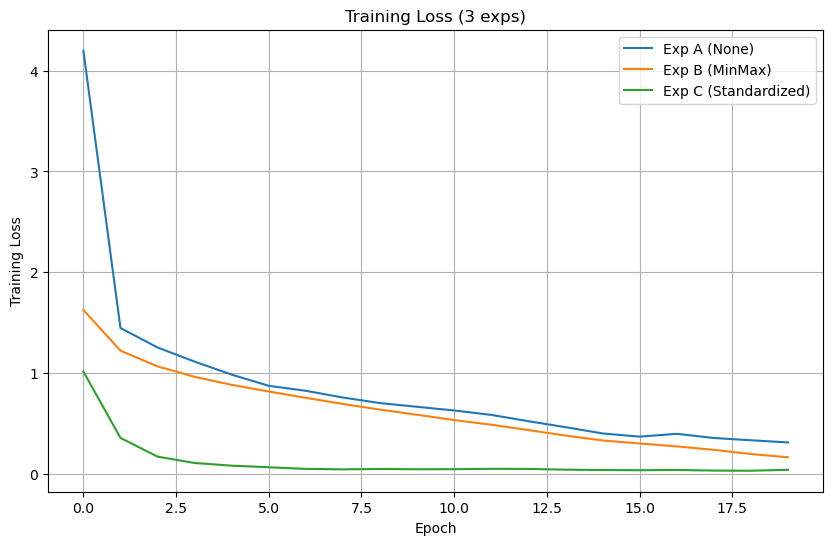

In [14]:
# Now let's gather the histories together to plot them out.
histories = [history_exp_a, history_exp_b, history_exp_c]
labels = ['Exp A (None)','Exp B (MinMax)','Exp C (Standardized)']

# Finally the plotting step 🤩
plot_curves(histories, labels, metric = 'val_accuracy', title = "Validation Accuracy (3 exps)", ylabel = "Val Accuracy")
plot_curves(histories, labels, metric = 'loss', title = "Training Loss (3 exps)", ylabel = "Training Loss")


In [15]:
# Experiment A: None (0-255)
train_acc_a = history_exp_a.history['accuracy'][-1]
val_acc_a = history_exp_a.history['val_accuracy'][-1]
test_acc_a = test_acc_exp_a
loss1_a = history_exp_a.history['loss'][0]

# Experiment B: Min-Max [0,1]
train_acc_b = history_exp_b.history['accuracy'][-1]
val_acc_b = history_exp_b.history['val_accuracy'][-1]
test_acc_b = test_acc_exp_b
loss1_b = history_exp_b.history['loss'][0]

# Experiment C: Standardized
train_acc_c = history_exp_c.history['accuracy'][-1]
val_acc_c = history_exp_c.history['val_accuracy'][-1]
test_acc_c = test_acc_exp_c
loss1_c = history_exp_c.history['loss'][0]

# Print as a table
print(f"{'Preprocessing':<15} {'Train Acc':<10} {'Val Acc':<10} {'Test Acc':<10} {'Loss @ Epoch 1':<15}")
print(f"{'None (0-255)':<15} {train_acc_a:.4f}    {val_acc_a:.4f}    {test_acc_a:.4f}    {loss1_a:.4f}")
print(f"{'Min-Max [0,1]':<15} {train_acc_b:.4f}    {val_acc_b:.4f}    {test_acc_b:.4f}    {loss1_b:.4f}")
print(f"{'Standardized':<15} {train_acc_c:.4f}    {val_acc_c:.4f}    {test_acc_c:.4f}    {loss1_c:.4f}")

Preprocessing   Train Acc  Val Acc    Test Acc   Loss @ Epoch 1 
None (0-255)    0.8935    0.5372    0.5314    4.1986
Min-Max [0,1]   0.9488    0.6718    0.6629    1.6243
Standardized    0.9884    0.6574    0.6560    1.0131


***

### Now, time to try something different, data augmentation 🧩

but first, let's see how training goes without it.

In [ ]:
model_no_aug = build_baseline_cnn()
history_no_aug, _, _, _ = train_and_evaluate(model_no_aug,
                                             x_train_exp_c, y_train,
                                             x_val_exp_c, y_val,
                                             x_test_exp_c, y_test,
                                             epochs = 40, batch_size = 128)

Test Acc: 0.4245 | Test Loss: 332.0450 | Time: 153.1s


### Let's now augment some data 😊

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
)

datagen.fit(x_train_exp_c)
model_aug = build_baseline_cnn()

history_aug = model_aug.fit(
    datagen.flow(x_train_exp_c, to_categorical(y_train, 10), batch_size = 128),
    validation_data = (x_val_exp_c, to_categorical(y_val, 10)),
    epochs = 40,
    steps_per_epoch = len(x_train_exp_c) // 128,
    verbose = 1 
)

Epoch 1/40


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4623 - loss: 1.5065 - val_accuracy: 0.5856 - val_loss: 1.1981
Epoch 2/40
  1/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6172 - loss: 1.3399

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6172 - loss: 1.3399 - val_accuracy: 0.5853 - val_loss: 1.2124
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5780 - loss: 1.1898 - val_accuracy: 0.6465 - val_loss: 1.0019
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5938 - loss: 1.0201 - val_accuracy: 0.6431 - val_loss: 1.0017
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6231 - loss: 1.0650 - val_accuracy: 0.6701 - val_loss: 0.9502
Epoch 6/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6641 - loss: 0.8979 - val_accuracy: 0.6692 - val_loss: 0.9573
Epoch 7/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6473 - loss: 1.0021 - val_accuracy: 0.6774 - val_loss: 0.9512
Epoch 8/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6641 - loss: 1.0282 - val_accuracy: 0.6720 - val_loss: 0.9620
Epoch 9/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6669 - loss: 0.9521 - val_accuracy: 0.687

### let's use the AI to save some time in the plotting 😅, this next bit of code was AI written but HI understood (Human Intelligence) 😂

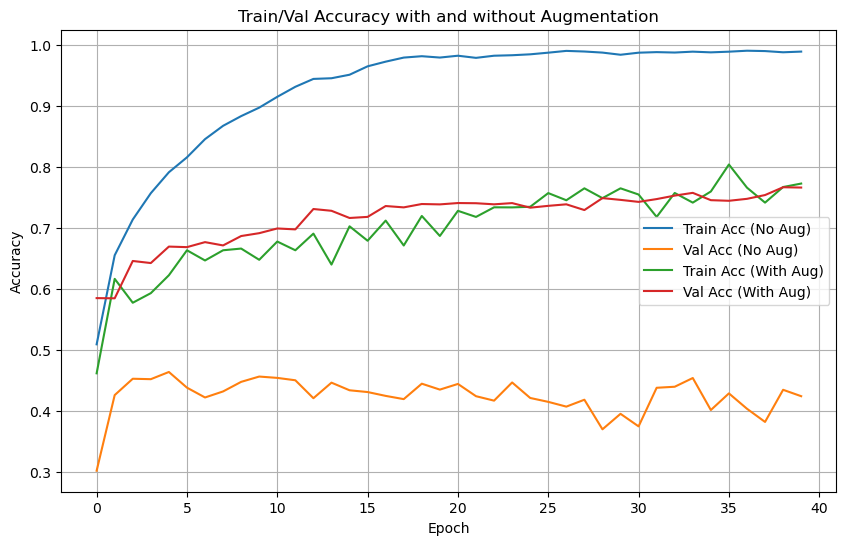

In [23]:
# Collect histories and labels
histories = [history_no_aug, history_aug]
labels = ['Train Acc (No Aug)', 'Train Acc (With Aug)']

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Val Accuracy with and without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

# Everything for the very first part of our expirments is done 🤩
تم بحمد الله وفضله 🩵